In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ausplay_raw = pd.read_excel(
    "C4S-AusPlay-By-Sport-Data-Tables-30-April-2026.xlsx",
    sheet_name="1",
    header=None
)

abs_raw = pd.read_excel(
    "31010do002_202512.xlsx",
    sheet_name="Table_8",
    header=None
)

print("AusPlay:", ausplay_raw.shape)
print("ABS:", abs_raw.shape)

AusPlay: (305, 13)
ABS: (334, 10)


/Users/calumchio/Library/Python/3.9/lib/python/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/Users/calumchio/Library/Python/3.9/lib/python/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [47]:
# AusPlay participation rates by sport and age group
start = ausplay_raw[ausplay_raw.iloc[:, 1].astype(str).str.strip()
                    .eq("Participation rate")].index[0]

end = ausplay_raw[ausplay_raw.iloc[:, 1].astype(str).str.strip()
                  .eq("Estimated number of participants")].index[0]

age_groups = ["15-17", "18-24", "25-34", "35-44",
              "45-54", "55-64", "65+"]

ausplay = ausplay_raw.iloc[start + 1:end, [0, 6, 7, 8, 9, 10, 11, 12]].copy()
ausplay.columns = ["Sport"] + age_groups

ausplay = ausplay.dropna(subset=["Sport"])

for col in age_groups:
    ausplay[col] = pd.to_numeric(ausplay[col], errors="coerce")

ausplay_long = ausplay.melt(
    id_vars="Sport",
    value_vars=age_groups,
    var_name="Age_Group",
    value_name="Participation_Rate"
).dropna()

ausplay_long["Participation_Percent"] = (
    ausplay_long["Participation_Rate"] * 100
)

ausplay_long.head()

,Sport,Age_Group,Participation_Rate,Participation_Percent
0,Adventure racing,15-17,0.000000,0.000000
1,Air sports,15-17,0.003524,0.352360
2,Archery,15-17,0.002829,0.282891
3,"Athletics, track and field",15-17,0.057526,5.752593
4,Australian football,15-17,0.060353,6.035263


In [48]:
# Extract ABS national population for PERSONS
persons_row = abs_raw[abs_raw.iloc[:, 0].astype(str).str.strip()
                      .eq("PERSONS")].index[0]

all_ages_row = abs_raw[
    (abs_raw.index > persons_row) &
    abs_raw.iloc[:, 0].astype(str).str.strip().eq("All ages")
].index[0]

abs_pop = abs_raw.loc[persons_row + 1:all_ages_row - 1, [0, 9]].copy()
abs_pop.columns = ["Age", "Population"]

abs_pop["Age_Number"] = pd.to_numeric(abs_pop["Age"], errors="coerce")
abs_pop["Population"] = pd.to_numeric(abs_pop["Population"], errors="coerce")

def pop(start, end):
    return abs_pop.loc[
        abs_pop["Age_Number"].between(start, end),
        "Population"
    ].sum()

population = {
    "15-17": pop(15, 17),
    "18-24": pop(18, 24),
    "25-34": pop(25, 34),
    "35-44": pop(35, 44),
    "45-54": pop(45, 54),
    "55-64": pop(55, 64),
    "65+": (
        pop(65, 84)
        + abs_pop.loc[
            abs_pop["Age"].astype(str).isin(
                ["85-89", "90-94", "95-99", "100 and over"]
            ),
            "Population"
        ].sum()
    )
}

population_df = pd.DataFrame(
    population.items(),
    columns=["Age_Group", "Population"]
)

combined_df = ausplay_long.merge(
    population_df,
    on="Age_Group",
    how="left"
)[["Sport", "Age_Group", "Population", "Participation_Percent"]]

print(combined_df.shape)
print(combined_df.isna().sum())

combined_df.head()

(994, 4)
Sport                    0
Age_Group                0
Population               0
Participation_Percent    0
dtype: int64


,Sport,Age_Group,Population,Participation_Percent
0,Adventure racing,15-17,1014970,0.000000
1,Air sports,15-17,1014970,0.352360
2,Archery,15-17,1014970,0.282891
3,"Athletics, track and field",15-17,1014970,5.752593
4,Australian football,15-17,1014970,6.035263


In [49]:
X = combined_df[["Sport", "Age_Group", "Population"]]
y = combined_df["Participation_Percent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["Sport", "Age_Group"]),
    ("num", StandardScaler(), ["Population"])
])

models = {
    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=5,
        random_state=42
    ),
    "SVR": SVR(kernel="rbf", C=10, epsilon=0.1)
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2": r2_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2
0,Decision Tree,1.093246,3.026807,0.274381
1,SVR,0.978478,2.640886,0.447619


In [50]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    mae = -cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="neg_mean_absolute_error"
    )

    print(name, "CV MAE:", round(mae.mean(), 3))

Decision Tree CV MAE: 1.496
SVR CV MAE: 1.319


In [51]:
feature_sets = {
    "AusPlay only": ["Sport", "Age_Group"],
    "AusPlay + ABS": ["Sport", "Age_Group", "Population"]
}

comparison = []

for feature_name, features in feature_sets.items():

    X = combined_df[features]
    y = combined_df["Participation_Percent"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    categorical = [x for x in features if x in ["Sport", "Age_Group"]]
    numeric = [x for x in features if x == "Population"]

    transformers = []

    if categorical:
        transformers.append(
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
        )

    if numeric:
        transformers.append(
            ("num", StandardScaler(), numeric)
        )

    prep = ColumnTransformer(transformers)

    for name, model in models.items():

        pipe = Pipeline([
            ("preprocessor", prep),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        comparison.append({
            "Data": feature_name,
            "Model": name,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "R2": r2_score(y_test, pred)
        })

comparison_df = pd.DataFrame(comparison)
comparison_df

,Data,Model,MAE,RMSE,R2
0,AusPlay only,Decision Tree,1.093246,3.026807,0.274381
1,AusPlay only,SVR,0.978407,2.448905,0.525011
2,AusPlay + ABS,Decision Tree,1.093246,3.026807,0.274381
3,AusPlay + ABS,SVR,0.978478,2.640886,0.447619


In [52]:
# Average participation by age group
age_summary = (
    combined_df.groupby("Age_Group")["Participation_Percent"]
    .mean()
    .sort_values(ascending=False)
)

# Average participation by sport
sport_summary = (
    combined_df.groupby("Sport")["Participation_Percent"]
    .mean()
    .sort_values(ascending=False)
)

print("Average participation by age group:")
print(age_summary)

print("\nTop 10 sports by average participation:")
print(sport_summary.head(10))

print("\nLowest 10 sports by average participation:")
print(sport_summary.tail(10))

Average participation by age group:
Age_Group
15-17    2.094473
18-24    1.847755
25-34    1.805485
35-44    1.630155
45-54    1.539126
55-64    1.427413
65+      0.961892
Name: Participation_Percent, dtype: float64

Top 10 sports by average participation:
Sport
Walking (Recreational)    47.781987
Fitness/Gym               35.050526
Running/jogging           18.259454
Bush walking              17.499205
Swimming                  15.891511
Cycling                    8.249137
Football/soccer            7.143873
Pilates                    6.973891
Basketball                 6.225326
Tennis                     5.594887
Name: Participation_Percent, dtype: float64

Lowest 10 sports by average participation:
Sport
Tobogganing         0.002329
Petanque            0.002222
Skirmish            0.002191
Broomball           0.002009
Wheelchair rugby    0.001914
Bobsledding         0.001831
Polo                0.000995
Boccia              0.000000
Luging              0.000000
Skeleton            0.

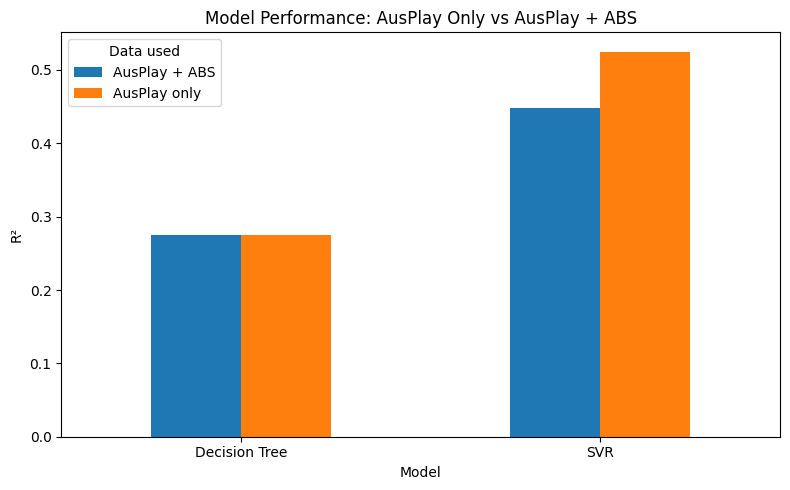

In [53]:
comparison_pivot = comparison_df.pivot(
    index="Model",
    columns="Data",
    values="R2"
)

comparison_pivot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("R²")
plt.xlabel("Model")
plt.title("Model Performance: AusPlay Only vs AusPlay + ABS")
plt.xticks(rotation=0)
plt.legend(title="Data used")
plt.tight_layout()
plt.show()

In [54]:
cv_results = []

for feature_name, features in feature_sets.items():

    X = combined_df[features]
    y = combined_df["Participation_Percent"]

    categorical = [x for x in features if x in ["Sport", "Age_Group"]]
    numeric = [x for x in features if x == "Population"]

    transformers = []

    if categorical:
        transformers.append(
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
        )

    if numeric:
        transformers.append(
            ("num", StandardScaler(), numeric)
        )

    prep = ColumnTransformer(transformers)

    for name, model in models.items():

        pipe = Pipeline([
            ("preprocessor", prep),
            ("model", model)
        ])

        mae = -cross_val_score(
            pipe, X, y, cv=5,
            scoring="neg_mean_absolute_error"
        ).mean()

        rmse = np.sqrt(
            -cross_val_score(
                pipe, X, y, cv=5,
                scoring="neg_mean_squared_error"
            ).mean()
        )

        r2 = cross_val_score(
            pipe, X, y, cv=5,
            scoring="r2"
        ).mean()

        cv_results.append({
            "Data": feature_name,
            "Model": name,
            "CV_MAE": mae,
            "CV_RMSE": rmse,
            "CV_R2": r2
        })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Data,Model,CV_MAE,CV_RMSE,CV_R2
0,AusPlay only,Decision Tree,0.971913,2.423484,0.829609
1,AusPlay only,SVR,1.141737,3.837404,0.574229
2,AusPlay + ABS,Decision Tree,0.971913,2.423484,0.829609
3,AusPlay + ABS,SVR,1.314420,4.579504,0.387918


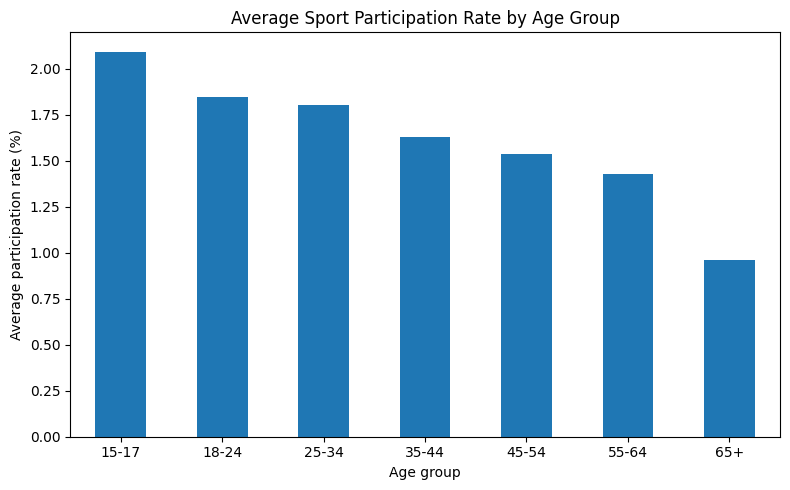

In [55]:
age_summary.sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Age group")
plt.ylabel("Average participation rate (%)")
plt.title("Average Sport Participation Rate by Age Group")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("age_participation.png", dpi=300, bbox_inches="tight")
plt.show()

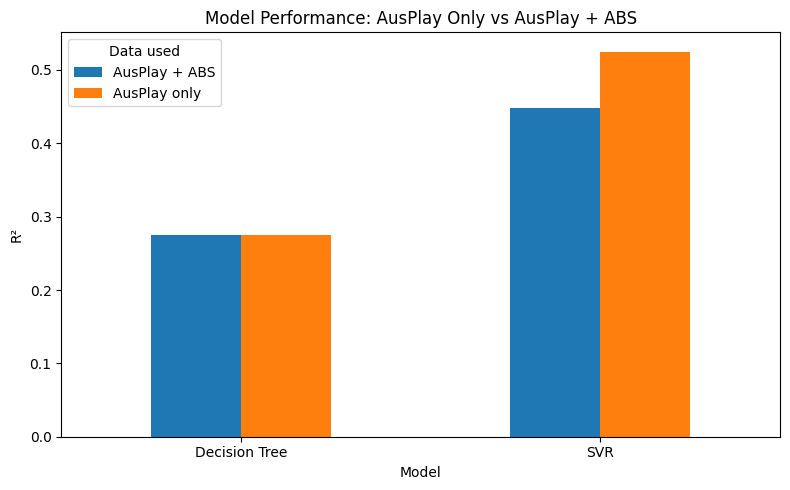

In [58]:
comparison_pivot = comparison_df.pivot(
    index="Model",
    columns="Data",
    values="R2"
)

comparison_pivot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("R²")
plt.xlabel("Model")
plt.title("Model Performance: AusPlay Only vs AusPlay + ABS")
plt.xticks(rotation=0)
plt.legend(title="Data used")
plt.tight_layout()

plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

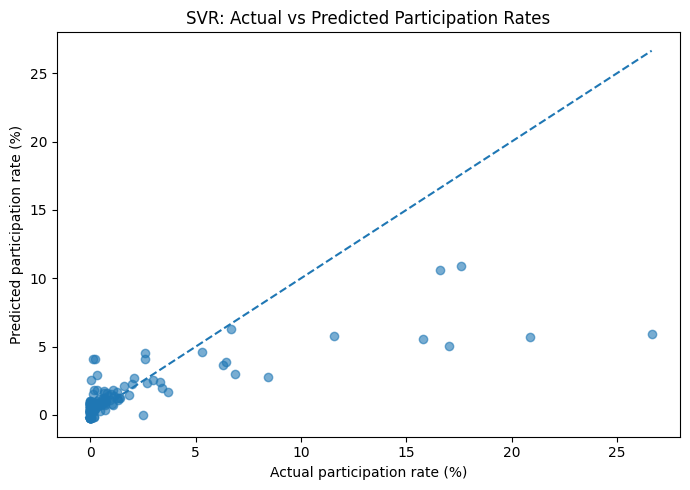

In [57]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, best_predictions, alpha=0.6)

min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual participation rate (%)")
plt.ylabel("Predicted participation rate (%)")
plt.title("SVR: Actual vs Predicted Participation Rates")
plt.tight_layout()

plt.savefig("svr_actual_predicted.png", dpi=300, bbox_inches="tight")
plt.show()